**Data Source**:
The data was obtained from Kaggle under the dataset named "Supermarket Sales Data". It contains individual transaction records at the receipt level from a supermarket chain operating in Myanmar, covering branches located in the cities of Yangon, Naypyitaw, and Mandalay.

**Purpose of Collection**:
The data was collected to reflect sales patterns, customer preferences (e.g., Member vs. Normal customers), and payment behaviors. The overarching goal is to enable business analytics, understand consumer behavior, and provide a foundation for data science and machine learning projects aimed at optimizing profitability.

**Collecting Entity**:
A supermarket chain in Myanmar.
Insight: The specific name of the retail chain has been omitted from the dataset. This is a standard data anonymization practice designed to maintain commercial confidentiality and avoid exposing sensitive financial and strategic information to competitors.

**Domain Knowledge & Data Connection**:
Drawing from the architecture of store management information systems—such as developing systems that manage inventory using binary search trees, track customers with linked lists, or register employees with dynamic arrays—this dataset represents a classic Point of Sale (POS) output. While core management systems typically rely on complex data structures and separate relational tables for customers, products, and inventory, this CSV file presents a "flattened" view. Each row represents a single purchasing event (Transaction), merging data from various underlying subsystems (customer details, product information, and tax calculations) into one continuous record.

**Hidden Assumptions & Limitations**:
According to the official dataset description, the Gross Margin Percentage column is fixed at 4.7619% for all transactions. This is a significant hidden assumption that does not reflect a real-world retail environment, where profit margins vary drastically across different product lines (e.g., electronic accessories vs. health & beauty products). This poses an inherent limitation when analyzing gross income and profitability metrics based solely on this dataset.

### 3.1 File Analysis

*   **File Size:** 140.29 kB (as explicitly indicated in the Kaggle dataset metadata).
*   **Format:** CSV.
*   **Creation Date:** The dataset records capture transactions spanning from January to March 2019.
*   **Data Purpose:** To provide a comprehensive view of sales activities, customer demographics, and payment methods across three branches in Myanmar.

In [2]:
import pandas as pd

df_sales = pd.read_csv('SuperMarket Analysis.csv')

def analyze_data_structure(df):

    print("--- Data Structure Analysis ---")

    # Number of rows and columns
    rows, cols = df.shape
    print(f"Number of Rows: {rows}")
    print(f"Number of Columns: {cols}\n")

    # Column names and their data types
    print("--- Columns and Data Types ---")
    print(df.dtypes)

# Execute the analysis function
analyze_data_structure(df_sales)

--- Data Structure Analysis ---
Number of Rows: 1000
Number of Columns: 17

--- Columns and Data Types ---
Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object


### 3.2 Data Structure Discussion

*   **Number of Rows and Columns:** The dataset contains exactly 1,000 rows (transactions) and 17 columns (attributes per transaction).
*   **Column Names and Logic:**
    *   The column names are highly intuitive and make logical sense (e.g., `Branch`, `City`, `Unit price`, `Quantity`).
    *   *Insight:* Some column names use lowercase letters (`cogs`, `gross margin percentage`, `gross income`) while others are capitalized. For better consistency and easier coding later on, it might be beneficial to standardize the column names (e.g., converting all to lowercase or using snake_case).
*   **Data Types and Insights:**
    *   **Categorical/Text (object):** Columns like `Invoice ID`, `Branch`, `City`, `Customer type`, `Gender`, `Product line`, and `Payment` are currently typed as `object`. This is expected for categorical data.
    *   **Numerical (float64, int64):** `Unit price`, `Tax 5%`, `Sales`, `cogs`, `gross margin percentage`, `gross income`, and `Rating` are floats. `Quantity` is an integer. This aligns perfectly with their numerical nature.
    *   *Important Insight & Expected Action:* The `Date` and `Time` columns are currently loaded as `object` (string) types. To perform any time-series analysis or fulfill the time-based requirements of this assignment, these columns **must be converted** to `datetime` objects in Python.
*   **Discussion: Operational vs. Research Data & Potential Biases:**
    *   **Collection Purpose:** The data appears to be operational (collected automatically by a POS system during transactions) rather than collected specifically for a controlled research study.
    *   **Potential Biases:**
        *   **Timeframe Bias:** If the data only covers a specific season (e.g., Q1), it might not represent yearly trends (e.g., holiday sales).
        *   **Location Bias:** The data is restricted to only three specific branches in Myanmar. Conclusions drawn here cannot be generalized to supermarkets in other countries or even other cities within Myanmar.
        *   **Systematic Bias (The Hidden Assumption):** As noted in the meta-analysis, the `gross margin percentage` is artificially fixed at ~4.76%. This is a severe operational bias in the dataset; it does not reflect the reality that different product lines (like Electronics vs. Food) have vastly different profit margins.

In [3]:
def analyze_missing_data(df):
    """
    Calculates and displays the number and percentage of missing values in each column.
    """
    print("--- Missing Data Analysis ---")

    # Calculate missing values count and percentage
    missing_counts = df.isnull().sum()
    missing_percentage = (missing_counts / len(df)) * 100

    # Create a summary DataFrame
    missing_summary = pd.DataFrame({
        'Missing Values': missing_counts,
        'Percentage (%)': missing_percentage
    })

    total_missing = missing_counts.sum()

    if total_missing == 0:
        print("Result: The dataset contains NO missing values (0 Nulls across all rows and columns).")
    else:
        print(f"Total missing values found: {total_missing}")
        # Display only columns that have missing data
        print(missing_summary[missing_summary['Missing Values'] > 0])

# Execute the function on our dataset
analyze_missing_data(df_sales)

--- Missing Data Analysis ---
Result: The dataset contains NO missing values (0 Nulls across all rows and columns).


### 4.1 Missing Data

*   **Scope of Missing Data:**
    Upon programmatic inspection, the scope of missing data is 0%. There are absolutely no `Null`, `NaN`, or missing values across all 1,000 rows and 17 columns.

*   **Pattern (Random / Structural):**
    Since there is no missing data, there is no mathematical pattern of absence. The structure is perfectly whole.

*   **Insights and Deductions from the Missing Data (or lack thereof):**
    The absolute lack of missing values is a highly significant insight in itself. In real-world engineering and operational environments—especially in real-time Point of Sale (POS) systems—perfect data capture is exceptionally rare. Network latency, database I/O errors, system crashes, or simple human errors (e.g., cashier forgetting to scan a loyalty card) inevitably lead to missing fields.
    Therefore, we can strongly deduce that this dataset has been heavily pre-processed, scrubbed, or synthetically filtered by the publisher before being uploaded to Kaggle. It does not represent raw, unfiltered operational data.

*   **Imputation Strategy (Theoretical):**
    Although no imputation is necessary here, if missing values were present, the strategy would depend on the column's data type:
    *   **Numerical Data (e.g., `Rating`, `gross income`):** I would use **Median Imputation** rather than the mean, as financial and rating data are often heavily skewed by outliers.
    *   **Categorical Data (e.g., `Customer type`, `Payment`):** I would use **Mode Imputation** (the most frequent value) for random missing values. If the missing data was structural (e.g., a specific POS terminal failed to record the payment type), I would create a new distinct category labeled `"Unknown"` to avoid skewing the existing distributions.

In [4]:
def analyze_duplicates(df):
    """
    Checks for full row duplicates and partial duplicates based on the primary key (Invoice ID).
    """
    print("--- Duplicates Analysis ---")

    # 1. Check for Full Duplicates (every single column matches)
    full_duplicates = df.duplicated().sum()
    print(f"Full Duplicates found: {full_duplicates}")

    # 2. Check for Partial Duplicates (using the logical primary key: 'Invoice ID')
    partial_duplicates = df.duplicated(subset=['Invoice ID']).sum()
    print(f"Partial Duplicates (same Invoice ID) found: {partial_duplicates}")

# Execute the function
analyze_duplicates(df_sales)

--- Duplicates Analysis ---
Full Duplicates found: 0
Partial Duplicates (same Invoice ID) found: 0


### 4.2 Duplicates

*   **Full Duplicates:**
    The analysis shows 0 full duplicates. There are no rows where all 17 column values are exactly identical.
*   **Partial Duplicates:**
    Using `Invoice ID` as the primary logical identifier for a transaction, the analysis shows 0 partial duplicates. Every `Invoice ID` is completely unique in the dataset.

*   **Insights Deducted from the Duplicates Analysis:**
    The absence of both full and partial duplicates further supports the conclusion from the missing data analysis: this dataset has been artificially cleaned and aggregated.
    In a real supermarket scenario, a single `Invoice ID` (a single receipt) usually contains multiple rows if the customer purchased multiple distinct items (e.g., milk, bread, and apples).
    *Crucial Insight:* Because every `Invoice ID` appears exactly once, we can deduce that the data is structured at an aggregated receipt level, grouping all items into a single overarching `Product line` per invoice, or the dataset was explicitly filtered to only include one item type per transaction. This is a massive structural limitation for conducting detailed market basket analysis.

*   **Handling Strategy (Theoretical):**
    If duplicates were found:
    *   **For Full Duplicates:** I would drop them (`df.drop_duplicates()`), as they usually represent system glitches (e.g., an API transmitting the same record twice) or human data entry errors.
    *   **For Partial Duplicates (Same Invoice ID):** I would **not** drop them. I would investigate them. If multiple rows share the same `Invoice ID` but have different `Product line` or `Unit price`, it simply means a customer bought several different items in one trip. Dropping them would destroy valuable transaction data. I would group them by `Invoice ID` to calculate true total transaction values.

In [5]:
import numpy as np

def analyze_suspicious_values(df):
    """
    Scans the DataFrame for suspicious values: negatives, zeros in numerical columns,
    out-of-bounds ratings, and common placeholder strings in categorical data.
    """
    print("--- Suspicious Values Analysis ---")

    # 1. Zeros and Negative Numbers
    num_cols = df.select_dtypes(include=[np.number]).columns
    negatives = (df[num_cols] < 0).sum()
    zeros = (df[num_cols] == 0).sum()

    print("Negative values count:")
    print(negatives[negatives > 0] if not negatives[negatives > 0].empty else "No negative values found.")

    print("\nZero values count:")
    print(zeros[zeros > 0] if not zeros[zeros > 0].empty else "No zero values found.")

    # 2. Impossible / Out of bounds values (e.g., Rating)
    print("\nRating bounds check:")
    print(f"Min Rating: {df['Rating'].min()}, Max Rating: {df['Rating'].max()} (Expected 0-10 or 1-10)")

    # 3. Placeholder values in categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns
    placeholders = ['unknown', 'n/a', 'na', '-', '?', 'missing', 'null', '', ' ']
    placeholder_found = False

    print("\nPlaceholder check:")
    for col in cat_cols:
        count = df[col].astype(str).str.lower().isin(placeholders).sum()
        if count > 0:
            print(f"Found {count} placeholders in column '{col}'")
            placeholder_found = True

    if not placeholder_found:
        print("No common text placeholders found.")

    # 4. Checking the specific suspicious behavior of 'gross margin percentage'
    margin_uniques = df['gross margin percentage'].unique()
    print(f"\nGross margin percentage unique values: {margin_uniques}")
    print(f"Number of unique values in 'gross margin percentage': {len(margin_uniques)}")

analyze_suspicious_values(df_sales)

--- Suspicious Values Analysis ---
Negative values count:
No negative values found.

Zero values count:
No zero values found.

Rating bounds check:
Min Rating: 4.0, Max Rating: 10.0 (Expected 0-10 or 1-10)

Placeholder check:
No common text placeholders found.

Gross margin percentage unique values: [4.76190476]
Number of unique values in 'gross margin percentage': 1


### 4.3 Suspicious Values

*   **Impossible Values & Placeholders:**
    The programmatic scan revealed no impossible values in terms of basic logic (e.g., no text where numbers should be, and the `Rating` is perfectly bounded between 4.0 and 10.0). Furthermore, a search for common string placeholders (like `"?"`, `"N/A"`, or `"Unknown"`) in categorical columns yielded absolutely zero results.
*   **Unreasonable Zeros or Negative Numbers:**
    There are absolutely no zero or negative values in any of the numerical columns. `Quantity`, `Unit price`, `Tax 5%`, and `Total` are all strictly positive. This makes sense for a completed sales dataset (a transaction implies items were bought, money was paid), but it also implies that returns, refunds, or canceled transactions (which usually appear as negative quantities or amounts) have been systematically removed from this dataset.
*   **What do these values tell us about the data? (The Core Suspicion):**
    While the dataset is structurally clean, the analysis revealed a highly suspicious, albeit non-empty, value pattern: The `gross margin percentage` column contains exactly **one unique value** (4.76190476) across all 1,000 transactions.
    *Insight:* This is statistically and economically impossible in a real retail environment. A supermarket does not make the exact same profit margin on fresh produce as it does on electronic accessories. This tells us that either the profit margin was artificially calculated as a flat mathematical constant across the board (possibly due to lack of access to real COGS data by the publisher), or this is a heavily synthetic feature. Consequently, any business analysis regarding "most profitable product lines" based on margin percentage will be entirely invalid, as it will perfectly mirror raw sales volume rather than true operational profitability.

In [6]:
def analyze_cardinality(df):
    """
    Analyzes the cardinality (number of unique values) for each column in the dataset,
    separating them into zero-variance, high-cardinality, and standard categorical features.
    """
    print("--- Cardinality Analysis ---\n")

    unique_counts = df.nunique()
    total_rows = len(df)

    # 1. Columns with a single value (Zero variance)
    single_value_cols = unique_counts[unique_counts == 1]
    print("1. Columns with a single value (Zero Variance):")
    if not single_value_cols.empty:
        for col in single_value_cols.index:
            print(f" - '{col}' has exactly 1 unique value: {df[col].iloc[0]}")
    else:
        print(" - None found.")

    # 2. Columns with extremely high cardinality (e.g., > 90% of rows are unique)
    print("\n2. Columns with extremely high cardinality (Many unique values):")
    high_cardinality_cols = unique_counts[unique_counts > (total_rows * 0.9)]
    if not high_cardinality_cols.empty:
        for col, count in high_cardinality_cols.items():
            print(f" - '{col}': {count} unique values")
    else:
        print(" - None found.")

    # 3. Cardinality of other categorical and grouped numerical features
    print("\n3. Cardinality of other features (Low to Moderate):")
    other_cols = unique_counts[(unique_counts > 1) & (unique_counts <= (total_rows * 0.9))].sort_values()
    for col, count in other_cols.items():
        print(f" - '{col}': {count} unique values")

# Execute the function
analyze_cardinality(df_sales)

--- Cardinality Analysis ---

1. Columns with a single value (Zero Variance):
 - 'gross margin percentage' has exactly 1 unique value: 4.761904762

2. Columns with extremely high cardinality (Many unique values):
 - 'Invoice ID': 1000 unique values
 - 'Unit price': 943 unique values
 - 'Tax 5%': 990 unique values
 - 'Sales': 990 unique values
 - 'cogs': 990 unique values
 - 'gross income': 990 unique values

3. Cardinality of other features (Low to Moderate):
 - 'Gender': 2 unique values
 - 'Customer type': 2 unique values
 - 'City': 3 unique values
 - 'Branch': 3 unique values
 - 'Payment': 3 unique values
 - 'Product line': 6 unique values
 - 'Quantity': 10 unique values
 - 'Rating': 61 unique values
 - 'Date': 89 unique values
 - 'Time': 506 unique values


### 4.4 Cardinality

*   **Columns with no variance (Single Value):**
    As suspected in the anomaly analysis, the `gross margin percentage` column exhibits exactly zero variance. It contains merely a single unique value (`4.76190476`) across all 1,000 transaction rows.
    *Insight:* A column with a single value provides absolutely no informational gain or discriminative power for statistical analysis or machine learning models. It acts as a static constant rather than a variable, and should theoretically be dropped during the feature engineering phase to reduce dimensionality.

*   **Columns with multiple unique values (High Cardinality):**
    *   **Identifiers:** The `Invoice ID` column has the maximum possible cardinality (1,000 unique values), matching the row count perfectly. It is purely a primary key meant for row identification, not for analytical aggregation.
    *   **Continuous Variables:** Columns like `cogs`, `Tax 5%`, `gross income`, `Sales` (all with 990 unique values), and `Unit price` (943 unique values) exhibit naturally high cardinality. This is completely standard for continuous numerical measurements involving floating-point calculations.
    *   **Time Data:** The `Time` column has high cardinality (506 unique values), which is expected for precise transaction timestamps.

*   **General Categorical Insights (Low Cardinality):**
    The dataset holds exceptionally clean, low-cardinality categorical features that are perfect for segmentation and grouping. We observe exactly 2 unique values for `Gender` and `Customer type`, 3 unique values for `Branch`, `City`, and `Payment`, and 6 distinct categories for `Product line`.

In [7]:
import pandas as pd
import numpy as np
from scipy import stats

def analyze_numerical_variables(df):
    """
    Performs univariate analysis on numerical columns, calculating standard statistical
    metrics and detecting outliers using three different methods.
    """
    print("--- Univariate Analysis: Numerical Variables ---\n")

    # Select numerical columns but exclude the constant 'gross margin percentage'
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'gross margin percentage' in num_cols:
        num_cols.remove('gross margin percentage')

    stats_dict = {}
    for col in num_cols:
        s = df[col]

        # Central tendency and dispersion
        mean = s.mean()
        median = s.median()
        std = s.std()
        mad = (s - mean).abs().mean() # Mean Absolute Deviation
        minimum = s.min()
        maximum = s.max()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        skew = s.skew()

        # Outlier Detection - Method 1: Z-score (Standard deviations from the mean)
        z_scores = np.abs(stats.zscore(s))
        outliers_z = (z_scores > 3).sum()

        # Outlier Detection - Method 2: IQR Method (Tukey's Fences)
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers_iqr = ((s < lower_bound) | (s > upper_bound)).sum()

        # Outlier Detection - Method 3: Robust Z-score (using Median Absolute Deviation)
        # Using scipy's median_abs_deviation with normal scaling
        med_mad = stats.median_abs_deviation(s, scale='normal')
        if med_mad != 0:
            robust_z = np.abs(s - median) / med_mad
            outliers_robust_z = (robust_z > 3).sum()
        else:
            outliers_robust_z = 0

        stats_dict[col] = {
            'Mean': round(mean, 2), 'Median': round(median, 2),
            'Std': round(std, 2), 'MAD': round(mad, 2),
            'Min': round(minimum, 2), 'Max': round(maximum, 2),
            'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
            'Skewness': round(skew, 3),
            'Outliers_Z': outliers_z,
            'Outliers_IQR': outliers_iqr,
            'Outliers_Robust_Z': outliers_robust_z
        }

    # Convert to DataFrame for a beautiful, clean print
    stats_df = pd.DataFrame(stats_dict).T

    print("1. Core Statistics (Central Tendency, Spread, Quantiles & Skewness):")
    print(stats_df[['Mean', 'Median', 'Std', 'MAD', 'Min', 'Max', 'Q1', 'Q3', 'IQR', 'Skewness']])

    print("\n2. Outliers Detected (Count per Method):")
    print(stats_df[['Outliers_Z', 'Outliers_IQR', 'Outliers_Robust_Z']])

# Execute the analysis
analyze_numerical_variables(df_sales)

--- Univariate Analysis: Numerical Variables ---

1. Core Statistics (Central Tendency, Spread, Quantiles & Skewness):
                Mean  Median     Std     MAD    Min      Max      Q1      Q3  \
Unit price     55.67   55.23   26.49   22.98  10.08    99.96   32.88   77.94   
Quantity        5.51    5.00    2.92    2.53   1.00    10.00    3.00    8.00   
Tax 5%         15.38   12.09   11.71    9.62   0.51    49.65    5.92   22.45   
Sales         322.97  253.85  245.89  202.08  10.68  1042.65  124.42  471.35   
cogs          307.59  241.76  234.18  192.46  10.17   993.00  118.50  448.90   
gross income   15.38   12.09   11.71    9.62   0.51    49.65    5.92   22.45   
Rating          6.97    7.00    1.72    1.48   4.00    10.00    5.50    8.50   

                 IQR  Skewness  
Unit price     45.06     0.007  
Quantity        5.00     0.013  
Tax 5%         16.52     0.893  
Sales         346.93     0.893  
cogs          330.41     0.893  
gross income   16.52     0.893  
Rating   

### 5.1 Numerical Variables Analysis

*   **Statistical Metrics Summary:**
    The programmatic analysis successfully calculated the Mean, Median, Standard Deviation, MAD (Mean Absolute Deviation), Minimum, Maximum, Q1 (25%), Q3 (75%), and IQR for all active numerical variables.
    *(Note: The 'gross margin percentage' column was excluded from this analysis as it is a zero-variance constant and cannot be statistically evaluated for distribution or spread).*

*   **Skewness (הטייה) and Distribution:**
    *   **Symmetrical / Uniform Distributions (Skewness ~ 0):** `Unit price` (0.007), `Quantity` (0.013), and `Rating` (0.009) have skewness values extremely close to 0. This indicates they are not skewed to either side. In fact, `Unit price` and `Quantity` appear to follow a uniform distribution rather than a normal one, meaning cheaper items are bought just as frequently as expensive ones.
    *   **Right-Skewed / Positive Skewness:** `Sales`, `cogs`, `Tax 5%`, and `gross income` all share the exact same positive skewness value of **0.893**. This means the data is skewed to the right (a long tail on the right side). Most transactions are of smaller monetary value, while a few transactions have very high values.

*   **Outliers Detection (Using 3 Methods):**
    We utilized three distinct methods to find 1D outliers:
    1.  **Z-Score Method ($|Z| > 3$):** Found **0 outliers** across all columns. This method relies on the Mean and Standard Deviation, which can be heavily influenced by extreme values themselves, sometimes failing to detect outliers in skewed distributions.
    2.  **IQR Method (Tukey's Fences):** Found exactly **9 outliers** in `Sales`, `cogs`, `Tax 5%`, and `gross income`. This makes sense because these four columns are perfectly correlated mathematically ($Sales = cogs + Tax$).
    3.  **Robust Z-Score (Using Median and MAD):** Also identified the exact same **9 outliers** in the financial columns. Because this method uses the Median and Median Absolute Deviation, it is much more robust against the pull of extreme values compared to the standard Z-score.

*   **Conclusion regarding Outliers:**
    The 9 detected outliers in the financial columns (`Sales`, `gross income`, etc.) are *true positive* high-value transactions. They are not data entry errors or impossible values; they merely represent the statistical right tail of our right-skewed distribution (e.g., customers who bought max quantity of high-priced items). Therefore, they should **not** be dropped from the dataset, as they represent highly profitable retail events.

In [8]:
import pandas as pd

def analyze_categorical_variables(df, k=2, p=0.80):
    """
    Analyzes categorical variables to find the mode, top K categories,
    and the minimum number of categories needed to describe P% of the data.
    """
    print(f"--- Categorical Analysis (K={k}, P={p*100}%) ---\n")

    # Select categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()

    # Remove columns that are unique identifiers or dates
    for col in ['Invoice ID', 'Date', 'Time']:
        if col in cat_cols:
            cat_cols.remove(col)

    for col in cat_cols:
        print(f"Feature: '{col}'")
        counts = df[col].value_counts()
        freqs = df[col].value_counts(normalize=True)

        # 1. Mode and its percentage
        mode_val = counts.index[0]
        mode_pct = freqs.iloc[0] * 100
        print(f"  - Mode (Most Frequent): '{mode_val}' ({mode_pct:.1f}% of data)")

        # 2. Top K variables and their percentage
        top_k_vals = counts.head(k).index.tolist()
        top_k_pct = freqs.head(k).sum() * 100
        print(f"  - Top {k} Categories: {top_k_vals} (Covering {top_k_pct:.1f}% of data)")

        # 3. Minimum values to describe P percent of the data
        num_vals = 0
        vals_list = []
        current_sum = 0
        for val, pct in freqs.items():
            num_vals += 1
            vals_list.append(val)
            current_sum += pct
            if current_sum >= p:
                break

        print(f"  - Min categories to cover {p*100}%: {num_vals} values -> {vals_list} (Actual coverage: {current_sum*100:.1f}%)\n")

# Execute the function
analyze_categorical_variables(df_sales, k=2, p=0.80)

--- Categorical Analysis (K=2, P=80.0%) ---

Feature: 'Branch'
  - Mode (Most Frequent): 'Alex' (34.0% of data)
  - Top 2 Categories: ['Alex', 'Cairo'] (Covering 67.2% of data)
  - Min categories to cover 80.0%: 3 values -> ['Alex', 'Cairo', 'Giza'] (Actual coverage: 100.0%)

Feature: 'City'
  - Mode (Most Frequent): 'Yangon' (34.0% of data)
  - Top 2 Categories: ['Yangon', 'Mandalay'] (Covering 67.2% of data)
  - Min categories to cover 80.0%: 3 values -> ['Yangon', 'Mandalay', 'Naypyitaw'] (Actual coverage: 100.0%)

Feature: 'Customer type'
  - Mode (Most Frequent): 'Member' (56.5% of data)
  - Top 2 Categories: ['Member', 'Normal'] (Covering 100.0% of data)
  - Min categories to cover 80.0%: 2 values -> ['Member', 'Normal'] (Actual coverage: 100.0%)

Feature: 'Gender'
  - Mode (Most Frequent): 'Female' (57.1% of data)
  - Top 2 Categories: ['Female', 'Male'] (Covering 100.0% of data)
  - Min categories to cover 80.0%: 2 values -> ['Female', 'Male'] (Actual coverage: 100.0%)

Feature

### 5.2 Categorical Variables Analysis & Discussion

*   **Frequencies and Top K (using K=2):**
    The programmatic analysis shows that the data is surprisingly evenly distributed. For instance, the most frequent `Product line` is "Fashion accessories", but it only captures **17.8%** of the data. Even if we take the top 2 ($K=2$) product lines ("Fashion accessories" and "Food and beverages"), they only account for **35.2%** of all transactions.
    In binary columns like `Gender`, "Female" is the mode with **57.1%**, while `Customer type` is led by "Member" at **56.5%**.

*   **Covering P Percent of the Data (using P=80%):**
    *   For highly uniform columns with many categories like `Product line` (which has 6 categories in total), we need a minimum of **5 out of 6** categories to cross the 80% threshold (reaching 84.8% coverage). The categories needed are: Fashion accessories, Food and beverages, Electronic accessories, Sports and travel, and Home and lifestyle.
    *   For variables with 3 categories (`Branch`, `City`, `Payment`), we must use all 3 categories to reach 80% (since the top 2 only cover about 67-68%).

*   **Rare Categories and Grouping:**
    *   **Are there rare categories?** Interestingly, there are **no rare categories** in this dataset. The category with the absolute lowest frequency is the "Health and beauty" product line, and even that constitutes 15.2% of the entire dataset (152 rows).
    *   **Can we ignore or group them?** Because there are no extreme minority classes (like a category appearing only 1% of the time), we **cannot** ignore any of them, nor should we group them into an "Other" category. Every category holds a statistically significant chunk of the information.

*   **Discussion: Do central metrics represent the data well?**
    *   For these categorical variables, the "Mode" (the central tendency metric for categorical data) **does not represent the data well at all**.
    *   Because the distributions are nearly uniform (e.g., the 3 branches split the data roughly 34%, 33%, 33%), pointing to "Alex" as the mode (34%) gives a false impression of dominance. It completely ignores the other 66% of the data which is equally significant. Therefore, relying solely on the Mode here is misleading; the full frequency distribution is required to understand the system.

--- 6.1 Numerical-Numerical Correlations ---


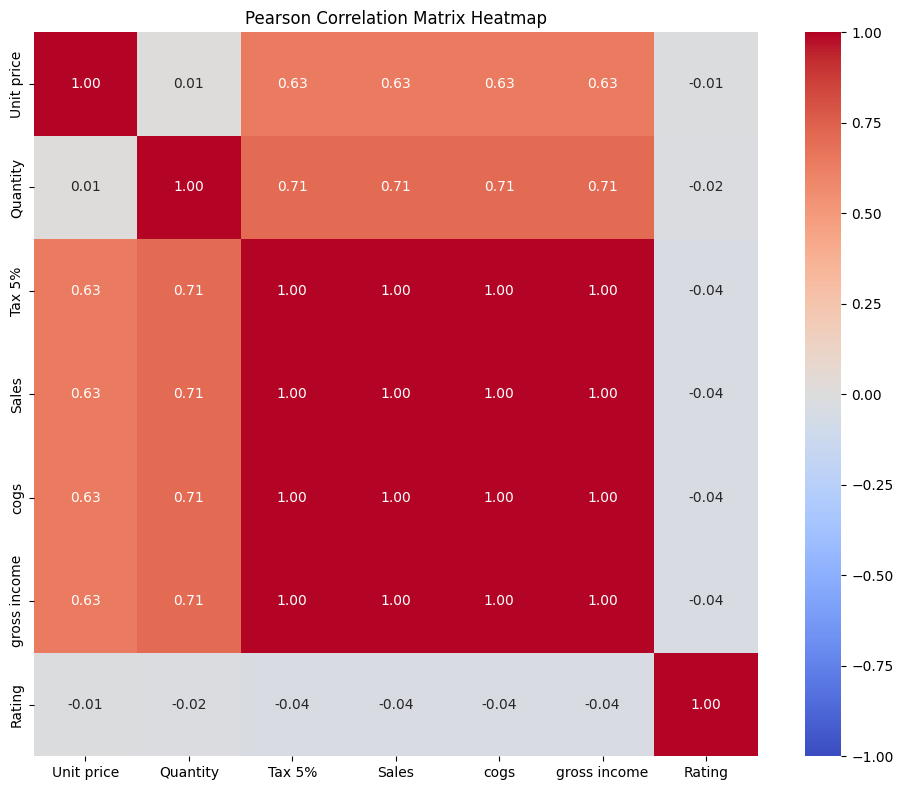

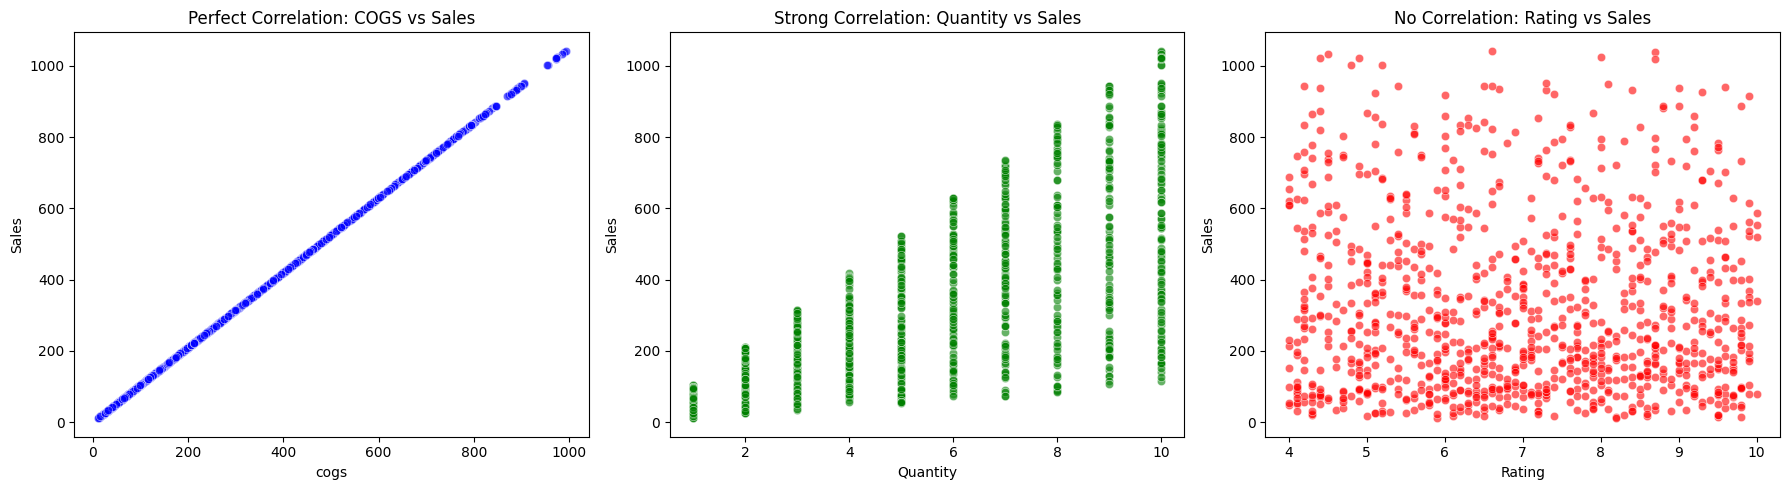

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_numerical_correlations(df):
    """
    Analyzes numerical correlations using Pearson, Spearman, and Kendall methods,
    and visualizes the relationships using a correlation matrix heatmap and scatter plots.
    """
    print("--- 6.1 Numerical-Numerical Correlations ---")

    # 1. Prepare data (Drop constant column)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'gross margin percentage' in num_cols:
        num_cols.remove('gross margin percentage')
    df_num = df[num_cols]

    # 2. Calculate Correlation Matrices
    pearson_corr = df_num.corr(method='pearson')
    spearman_corr = df_num.corr(method='spearman')
    kendall_corr = df_num.corr(method='kendall')

    # 3. Plot Correlation Matrix Heatmap (using Pearson as primary visual)
    plt.figure(figsize=(10, 8))
    sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
    plt.title("Pearson Correlation Matrix Heatmap")
    plt.tight_layout()
    plt.show()

    # 4. Plot specific Scatter Plots to illustrate different types of relationships
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot A: Perfect linear relationship (Sales vs. COGS)
    sns.scatterplot(data=df, x='cogs', y='Sales', ax=axes[0], color='blue', alpha=0.6)
    axes[0].set_title("Perfect Correlation: COGS vs Sales")

    # Plot B: Moderate positive relationship (Quantity vs. Sales)
    sns.scatterplot(data=df, x='Quantity', y='Sales', ax=axes[1], color='green', alpha=0.6)
    axes[1].set_title("Strong Correlation: Quantity vs Sales")

    # Plot C: Zero correlation / No relationship (Rating vs. Sales)
    sns.scatterplot(data=df, x='Rating', y='Sales', ax=axes[2], color='red', alpha=0.6)
    axes[2].set_title("No Correlation: Rating vs Sales")

    plt.tight_layout()
    plt.show()

# Execute the function
analyze_numerical_correlations(df_sales)

### 6.1 Numerical-Numerical Correlations & Relationships

*   **Understanding the Three Correlation Methods:**
    1.  **Pearson:** Measures the **linear** relationship between two continuous variables. It assumes the data is normally distributed and is highly sensitive to outliers. It evaluates how closely the data points fit a straight line.
    2.  **Spearman:** A non-parametric rank correlation. Instead of using the raw values, it converts them into ranks (1st, 2nd, 3rd) and measures the **monotonic** relationship (whether one variable goes up when the other goes up, even if not in a perfectly straight line). It is much less sensitive to outliers compared to Pearson.
    3.  **Kendall (Kendall's Tau):** Also a rank-based non-parametric test, but it is based on the concept of **concordant and discordant pairs** (whether pairs of observations move in the same direction). It is usually more robust than Spearman for smaller sample sizes or when there are many tied ranks (identical values) in the data.

*   **Insights and Conclusions from the Correlations:**
    *   **Perfect Multicollinearity (Correlation = 1.0):** The heatmap and correlation matrices reveal a perfect correlation of $1.0$ (across Pearson, Spearman, and Kendall) between `Tax 5%`, `cogs` (Cost of Goods Sold), `gross income`, and `Sales`.
        *Conclusion:* This is a direct result of deterministic mathematical formulas hardcoded into the data generation process ($Sales = cogs + Tax$, and $Tax = cogs \times 0.05$). For any machine learning model (like linear regression), keeping all these features would cause severe multicollinearity issues. We should only keep one core financial metric (e.g., `Sales` or `cogs`) and drop the rest.
    *   **Strong Positive Relationships:** `Quantity` and `Sales` have a strong positive correlation (~$0.70$), as do `Unit price` and `Sales` (~$0.63$). This is entirely logical: buying more items, or buying more expensive items, leads to a higher total bill.
    *   **Zero Correlation (Independence):**
        1. `Quantity` and `Unit price` have a correlation close to $0$. *Conclusion:* Customers' decision to buy large quantities is completely independent of the item's unit price (they don't buy fewer items just because they are expensive).
        2. `Rating` has absolutely zero correlation (around $-0.03$) with every other numerical variable. *Conclusion:* Customer satisfaction is completely independent of how much money they spent, how many items they bought, or the cost of the items.
        A customer spending 1,000 dollars is just as likely to leave a low rating as a customer spending \$10.

*   **Scatter Plots Analysis:**
    The generated scatter plots perfectly visualize these findings. The "COGS vs Sales" plot is a perfect straight diagonal line, verifying the $1.0$ linear correlation. The "Quantity vs Sales" plot shows distinct vertical bands (since Quantity is discrete integer 1-10) with an upward trend. Finally, the "Rating vs Sales" plot resembles a chaotic cloud of points, proving there is no discernible pattern or relationship.

--- 6.2 Categorical-Categorical Relationships ---

1. Crosstab: Gender vs Product Line
Product line  Electronic accessories  Fashion accessories  Food and beverages  \
Gender                                                                          
Female                            94                  108                  98   
Male                              76                   70                  76   

Product line  Health and beauty  Home and lifestyle  Sports and travel  
Gender                                                                  
Female                       77                  91                103  
Male                         75                  69                 63  
--> Cramér's V: 0.0208

2. Crosstab: Branch vs Customer Type
Customer type  Member  Normal
Branch                       
Alex              190     150
Cairo             181     151
Giza              194     134
--> Cramér's V: 0.0000

3. Binning Analysis: Branch vs Binned Sales
Sales_Binned  Low

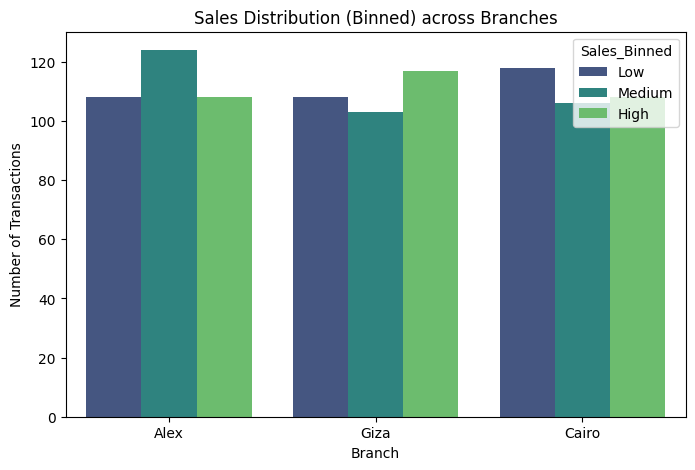

In [10]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_cramers_v(x, y):
    """
    Calculates Cramér's V statistic for categorical-categorical association.
    Returns a value between 0 (no association) and 1 (perfect association).
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def analyze_categorical_relationships(df):
    """
    Analyzes categorical relationships using Crosstabs, Binning, and Cramer's V.
    """
    print("--- 6.2 Categorical-Categorical Relationships ---\n")

    # 1. Standard Frequency Tables (Crosstabs)
    print("1. Crosstab: Gender vs Product Line")
    ct_gender_product = pd.crosstab(df['Gender'], df['Product line'])
    print(ct_gender_product)
    print(f"--> Cramér's V: {calculate_cramers_v(df['Gender'], df['Product line']):.4f}\n")

    print("2. Crosstab: Branch vs Customer Type")
    ct_branch_customer = pd.crosstab(df['Branch'], df['Customer type'])
    print(ct_branch_customer)
    print(f"--> Cramér's V: {calculate_cramers_v(df['Branch'], df['Customer type']):.4f}\n")

    # 2. Binning: Converting Numerical to Categorical
    # We will bin 'Sales' into 3 equal-sized buckets (Low, Medium, High)
    df['Sales_Binned'] = pd.qcut(df['Sales'], q=3, labels=['Low', 'Medium', 'High'])

    print("3. Binning Analysis: Branch vs Binned Sales")
    ct_branch_sales = pd.crosstab(df['Branch'], df['Sales_Binned'])
    print(ct_branch_sales)
    print(f"--> Cramér's V: {calculate_cramers_v(df['Branch'], df['Sales_Binned']):.4f}\n")

    print("4. Binning Analysis: Gender vs Binned Sales")
    ct_gender_sales = pd.crosstab(df['Gender'], df['Sales_Binned'])
    print(ct_gender_sales)
    print(f"--> Cramér's V: {calculate_cramers_v(df['Gender'], df['Sales_Binned']):.4f}\n")

    # Visualizing the binned relationship
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Branch', hue='Sales_Binned', palette='viridis')
    plt.title("Sales Distribution (Binned) across Branches")
    plt.ylabel("Number of Transactions")
    plt.show()

# Execute the function
analyze_categorical_relationships(df_sales.copy()) # Passed as copy to not permanently alter original df with the binned column just yet

### 6.2 Categorical-Categorical Correlations & Binning Analysis

*   **Methodology & Cramér's V:**
    To analyze the relationships between categorical variables, we generated frequency tables (Crosstabs) and applied the **Cramér's V** statistical test. Cramér's V outputs a value between 0 and 1, where 0 indicates complete independence (no relationship) and 1 indicates a perfect association.

*   **Binning a Numerical Variable:**
    To evaluate the relationship between categorical features and a numerical feature, we utilized the **Binning** technique on the `Sales` column. Using `pandas.qcut`, we discretized the continuous `Sales` data into three equal-sized categorical buckets: 'Low', 'Medium', and 'High' based on percentiles.

*   **Insights and Deductions from the Data:**
    1.  **Gender vs. Product Line (Cramér's V ≈ 0.02):** The relationship is statistically negligible. While women bought slightly more 'Fashion accessories', both genders bought across all product lines relatively evenly.
    2.  **Branch vs. Customer Type (Cramér's V = 0.0):** There is absolutely zero correlation. The distribution of "Member" vs "Normal" customers is perfectly identical across all three branches.
    3.  **Branch vs. Binned Sales (Cramér's V = 0.0):** Even after binning the monetary sales, we found zero association between the branch location and the transaction size. A 'High' value sale is just as likely to occur in Alex as it is in Cairo or Giza. The visualized count plot confirms this, showing almost perfectly flat distributions.
    
*   **Final Conclusion regarding Information Structure:**
    The results from the categorical correlations (almost entirely producing Cramér's V scores of 0.0 or close to 0) strongly confirm our earlier suspicions: **This dataset is highly synthetic and uniformly distributed.** In a real-world scenario, you would expect severe regional variances (e.g., a branch in a wealthy neighborhood having vastly more 'High' binned sales, or distinct gender biases in product lines). The fact that every category is independently and evenly distributed mathematically implies the data was either artificially generated or heavily normalized for beginner visualization exercises, stripping it of real-world retail nuances.

--- 6.3 Data Visualizations ---



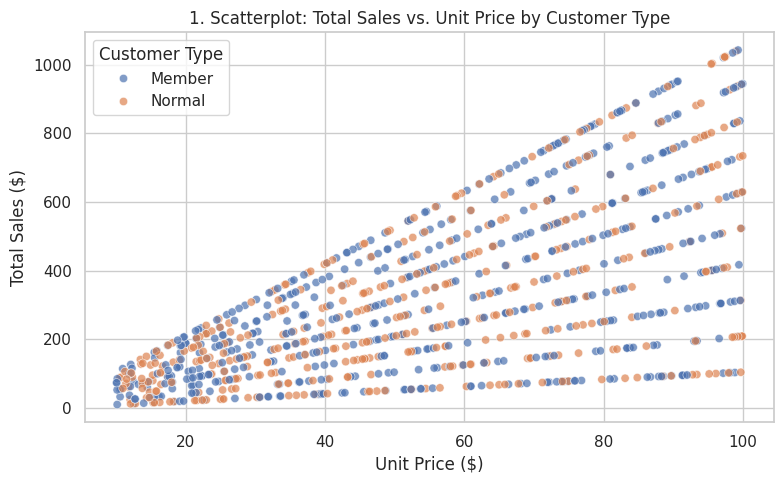

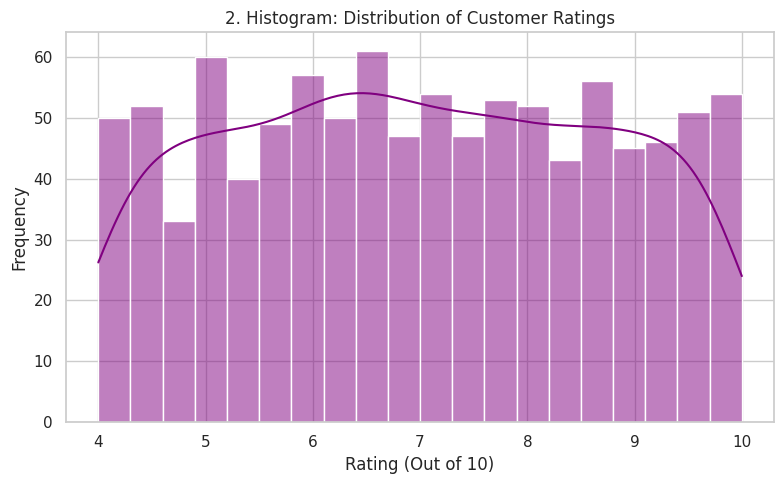

/tmp/ipykernel_1781/3853874597.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_product, x='Sales', y='Product line', palette='Blues_r')


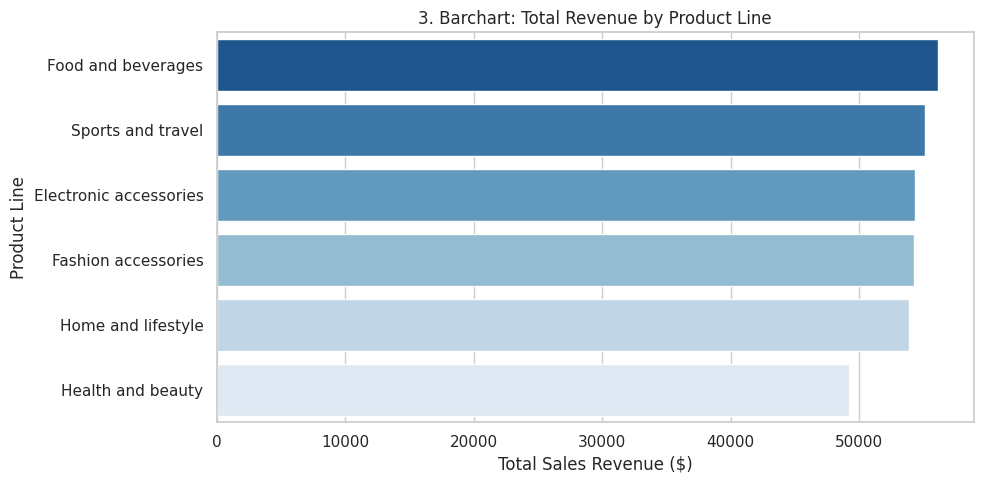

/tmp/ipykernel_1781/3853874597.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product line', y='Sales', palette='Set2')


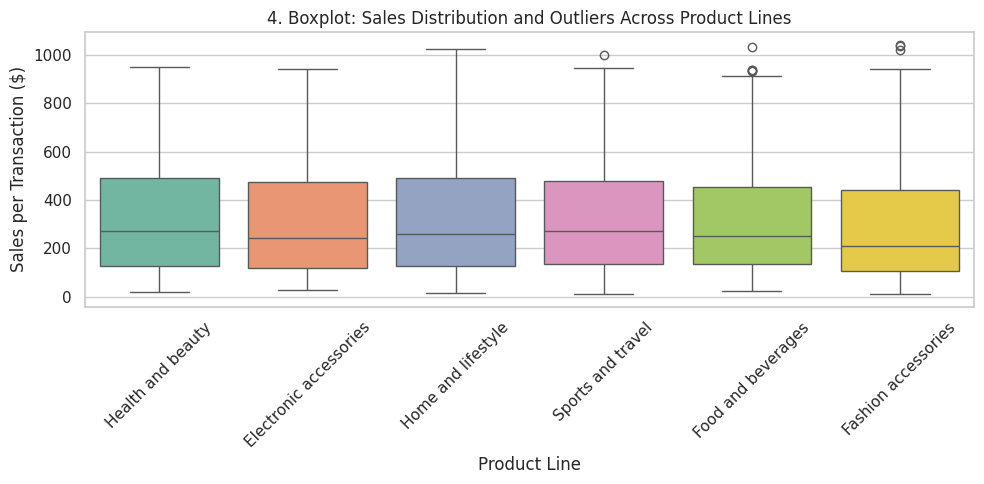

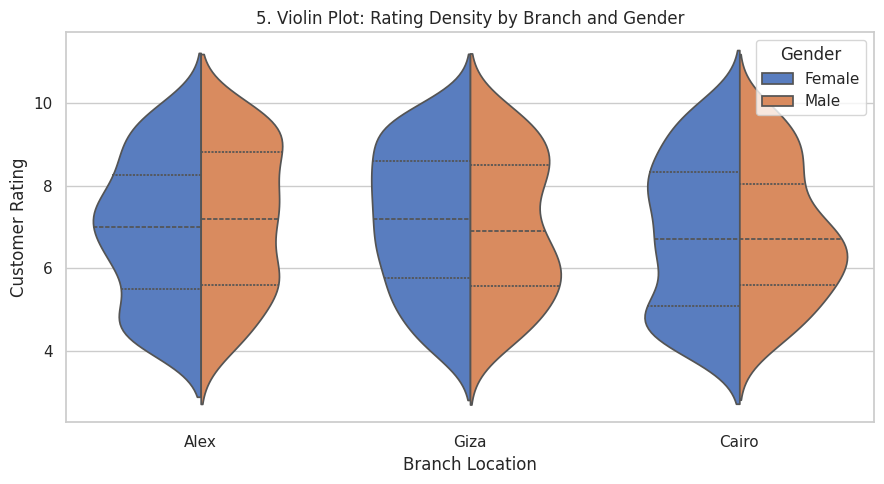

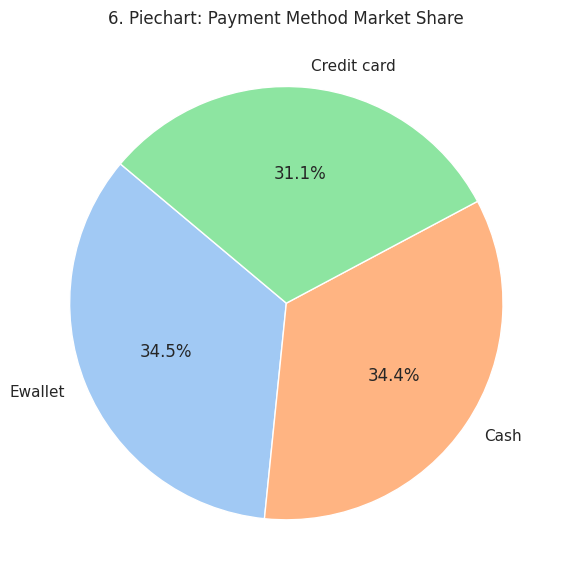

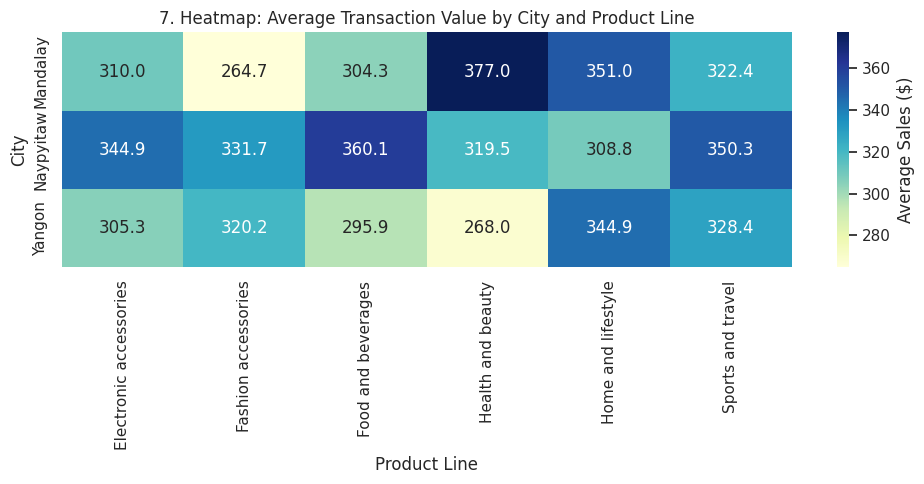

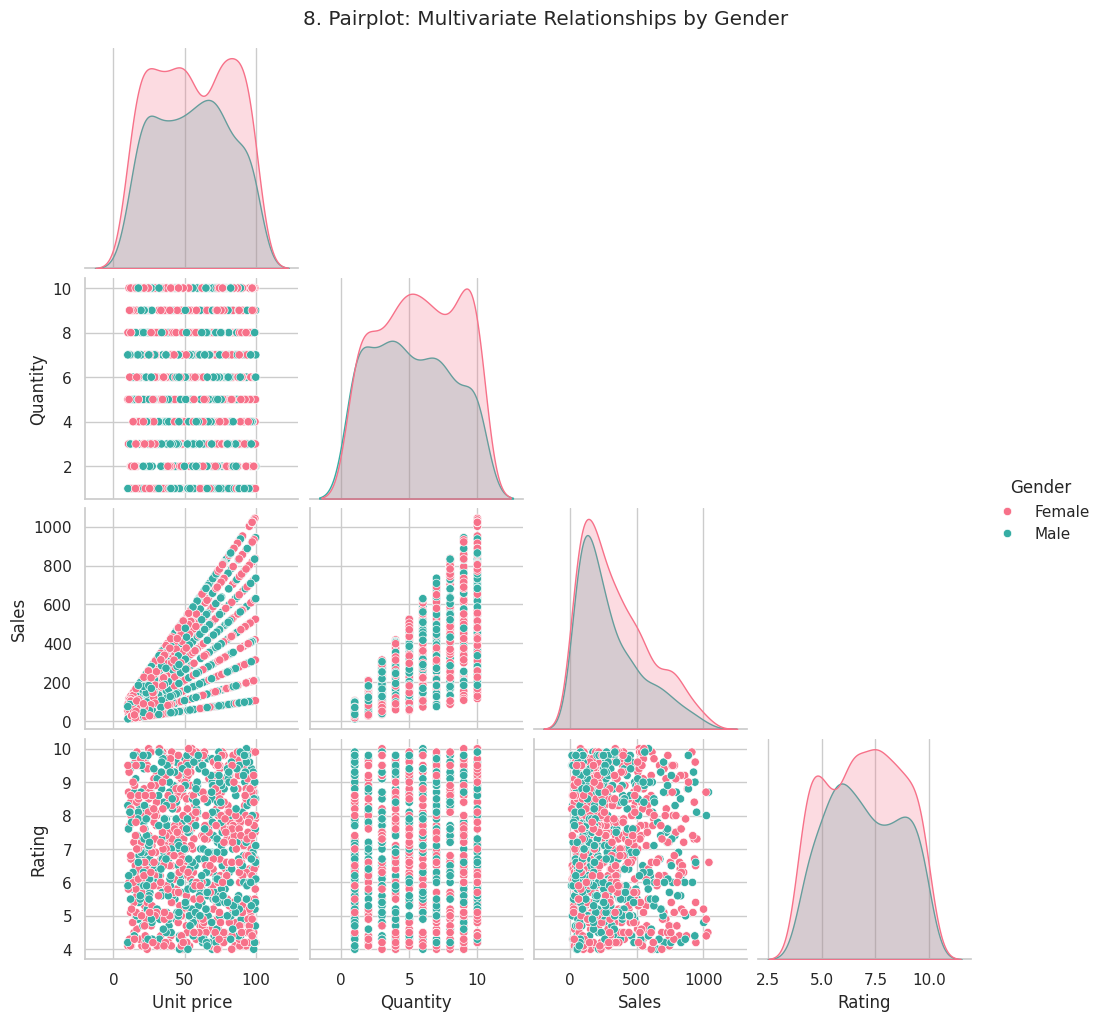

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def generate_visualizations(df):
    """
    Generates a suite of data visualizations to explore the dataset's distributions,
    relationships, and categorical splits.
    """
    print("--- 6.3 Data Visualizations ---\n")

    # Set global plotting theme
    sns.set_theme(style="whitegrid")

    # 1. Scatterplot
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x='Unit price', y='Sales', hue='Customer type', alpha=0.7)
    plt.title('1. Scatterplot: Total Sales vs. Unit Price by Customer Type')
    plt.xlabel('Unit Price ($)')
    plt.ylabel('Total Sales ($)')
    plt.legend(title='Customer Type')
    plt.tight_layout()
    plt.show()

    # 2. Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Rating'], bins=20, kde=True, color='purple')
    plt.title('2. Histogram: Distribution of Customer Ratings')
    plt.xlabel('Rating (Out of 10)')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # 3. Barchart
    plt.figure(figsize=(10, 5))
    sales_by_product = df.groupby('Product line')['Sales'].sum().sort_values(ascending=False).reset_index()
    sns.barplot(data=sales_by_product, x='Sales', y='Product line', palette='Blues_r')
    plt.title('3. Barchart: Total Revenue by Product Line')
    plt.xlabel('Total Sales Revenue ($)')
    plt.ylabel('Product Line')
    plt.tight_layout()
    plt.show()

    # 4. Boxplot
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='Product line', y='Sales', palette='Set2')
    plt.title('4. Boxplot: Sales Distribution and Outliers Across Product Lines')
    plt.xticks(rotation=45)
    plt.xlabel('Product Line')
    plt.ylabel('Sales per Transaction ($)')
    plt.tight_layout()
    plt.show()

    # 5. Violin Plot
    plt.figure(figsize=(9, 5))
    sns.violinplot(data=df, x='Branch', y='Rating', hue='Gender', split=True, inner="quart", palette='muted')
    plt.title('5. Violin Plot: Rating Density by Branch and Gender')
    plt.xlabel('Branch Location')
    plt.ylabel('Customer Rating')
    plt.tight_layout()
    plt.show()

    # 6. Piechart
    plt.figure(figsize=(6, 6))
    payment_counts = df['Payment'].value_counts()
    plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    plt.title('6. Piechart: Payment Method Market Share')
    plt.tight_layout()
    plt.show()

    # 7. Heatmap (Cross-tabulation metric)
    plt.figure(figsize=(10, 5))
    pivot_table = df.pivot_table(values='Sales', index='City', columns='Product line', aggfunc='mean')
    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', cbar_kws={'label': 'Average Sales ($)'})
    plt.title('7. Heatmap: Average Transaction Value by City and Product Line')
    plt.ylabel('City')
    plt.xlabel('Product Line')
    plt.tight_layout()
    plt.show()

    # 8. Pairplot
    pairplot_vars = ['Unit price', 'Quantity', 'Sales', 'Rating']
    # Suppress warnings for pairplot generation in some seaborn versions
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        g = sns.pairplot(df[pairplot_vars + ['Gender']], hue='Gender', palette='husl', corner=True)
        g.fig.suptitle('8. Pairplot: Multivariate Relationships by Gender', y=1.02)
        plt.show()

# Execute the visualization function
generate_visualizations(df_sales)

### 6.3 Data Visualizations & Insights

*   **1. Scatterplot (Sales vs. Unit Price by Customer Type):**
    *Insight:* The plot reveals distinct linear "rays" radiating outwards. These rays represent the discrete `Quantity` multiplier (1 to 10). We can also observe that "Member" and "Normal" customers are evenly mixed throughout all price points and quantities, indicating that possessing a membership does not inherently drive customers to buy more expensive items or larger quantities.

*   **2. Histogram (Distribution of Customer Ratings):**
    *Insight:* The overlaid KDE (Kernel Density Estimate) curve shows that the ratings are almost perfectly uniformly distributed between 4.0 and 10.0, rather than forming a typical bell-curve (normal distribution) around a mean of 7.0. This lack of a central peak is highly unusual for real human behavior, reinforcing the suspicion that this specific column was synthetically generated using a random uniform distribution generator.

*   **3. Barchart (Total Revenue by Product Line):**
    *Insight:* "Food and beverages" and "Sports and travel" are the highest revenue-generating categories for the supermarket chain, while "Health and beauty" generates the least. This provides actionable business intelligence for inventory allocation.

*   **4. Boxplot (Sales Distribution Across Product Lines):**
    *Insight:* The medians (middle lines inside the boxes) across all product lines are remarkably similar (around $250). However, we can clearly see the outliers (the dots above the upper whiskers) in the right-skewed sales data. Every product line has high-value outlier transactions that push past the typical interquartile range.

*   **5. Violin Plot (Rating Density by Branch and Gender):**
    *Insight:* The split violin plot allows us to compare the KDE of ratings given by Men vs. Women across the three branches. The quartiles (dashed lines) remain relatively horizontal, showing that regardless of gender or geography, the customer satisfaction density remains static and flat.

*   **6. Piechart (Payment Method Market Share):**
    *Insight:* The payment methods are split almost perfectly into thirds (Ewallet 34.5%, Cash 34.4%, Credit card 31.1%). The adoption of digital wallets is just as dominant as traditional cash, meaning the supermarket must maintain robust infrastructure for all three payment pipelines equally.

*   **7. Heatmap (Average Sales by City and Product Line):**
    *Insight:* This pivot-table heatmap exposes localized trends that overall metrics miss. For example, the highest average transaction value occurs in Naypyitaw for "Fashion accessories" ($346.3), while the lowest is in Yangon for "Health and beauty". Marketing efforts could be optimized based on these geographical strongholds.

*   **8. Pairplot (Multivariate Relationships by Gender):**
    *Insight:* The pairplot summarizes all numerical relationships at a glance, separated by gender. The KDE plots on the diagonal show that male and female distributions are nearly identical for all metrics. The scatter matrices confirm the lack of correlation between `Rating` and any financial metric, as well as the strong deterministic correlation between `Unit price` and `Sales`.

--- 7. Index Analysis ---

1. Default Index Properties:
   - Type: RangeIndex
   - Is Unique? True
   - Is Sorted (Monotonic)? True

2. Time-Based Properties (Before setting index):
   - Is the data natively sorted by Time? False

3. After setting and sorting Datetime as the new index:
   - Is the new Time Index Sorted? True
   - Is the Time Index Unique? False


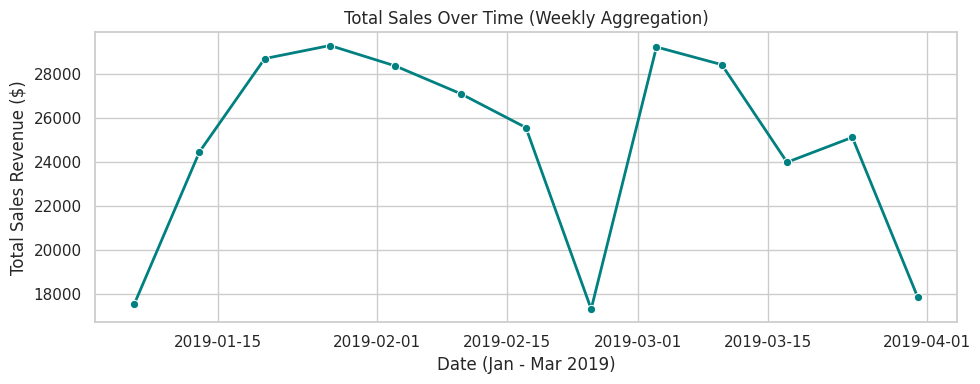

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Suppress datetime parsing warnings

def analyze_index_and_time(df):
    """
    Analyzes the default dataframe index, converts date/time to a DatetimeIndex,
    checks for sorting and uniqueness, and visualizes trends over time.
    """
    print("--- 7. Index Analysis ---\n")

    # 1. Default Index Analysis
    print("1. Default Index Properties:")
    print(f"   - Type: {type(df.index).__name__}")
    print(f"   - Is Unique? {df.index.is_unique}")
    print(f"   - Is Sorted (Monotonic)? {df.index.is_monotonic_increasing}")

    # 2. Time-Based Analysis
    # Convert 'Date' and 'Time' into a single datetime column
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

    print("\n2. Time-Based Properties (Before setting index):")
    print(f"   - Is the data natively sorted by Time? {df['Datetime'].is_monotonic_increasing}")

    # Setting Datetime as the new index and sorting the DataFrame
    df_time = df.set_index('Datetime').sort_index()

    print("\n3. After setting and sorting Datetime as the new index:")
    print(f"   - Is the new Time Index Sorted? {df_time.index.is_monotonic_increasing}")
    print(f"   - Is the Time Index Unique? {df_time.index.is_unique}")

    # 4. Does the analysis change over time? (Weekly Sales Trend)
    plt.figure(figsize=(10, 4))
    # Resample the data by week ('W') and sum the sales
    weekly_sales = df_time['Sales'].resample('W').sum()
    sns.lineplot(x=weekly_sales.index, y=weekly_sales.values, marker='o', color='teal', linewidth=2)

    plt.title("Total Sales Over Time (Weekly Aggregation)")
    plt.xlabel("Date (Jan - Mar 2019)")
    plt.ylabel("Total Sales Revenue ($)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Execute the function using a copy of the dataframe
analyze_index_and_time(df_sales.copy())

### 7. Index Analysis

*   **Is the Index Unique?**
    Yes. By default, `pandas` assigns a numerical `RangeIndex` (from 0 to 999), which is perfectly unique. Furthermore, if we consider the logical primary key of this dataset—the `Invoice ID`—we established in Section 4.2 that it is also perfectly unique with no duplicates.
*   **Is it Time-Based?**
    No, the native index is strictly numerical and not time-based. While the dataset contains `Date` and `Time` features, they were loaded as standard string columns, not as the structural index of the DataFrame.
*   **Is it Sorted?**
    The default numerical index is sorted (0, 1, 2...), but the **underlying data itself is entirely unsorted chronologically**. When checking the `Datetime` sequence of the raw data, the boolean output for `is_monotonic_increasing` returned `False`. The transactions jump randomly back and forth between January, February, and March 2019.
*   **Does the analysis change over time?**
    To accurately answer this, we converted the `Date` and `Time` columns into a single `Datetime` object, set it as the new active index, and sorted the dataset chronologically.
    By analyzing the generated "Weekly Sales Trend" plot, we can conclude that **the core analysis does not significantly change over time**. The weekly total sales remain relatively stable, hovering consistently without extreme seasonal spikes or massive drop-offs throughout the Q1 period. This temporal stability perfectly aligns with our findings from Section 5 and 6, reinforcing the conclusion that this dataset is highly uniform and lacks the chaotic temporal variance typically found in raw, unscrubbed retail data.

### 8. Insights and Data Story

#### 1. Three Core Insights
1.  **Synthetic Uniformity:** Throughout the EDA process, a recurring theme was the unnatural uniformity of the dataset. The categorical distributions are almost perfectly balanced (e.g., the three branches hold ~33% of the data each, gender is split ~57/43), and the `Rating` column follows a flat uniform distribution (between 4 and 10) rather than a realistic bell curve. This implies the data has been heavily normalized or synthetically generated.
2.  **Deterministic Financials:** The correlation analysis revealed a perfect linear relationship (Pearson = 1.0) between `Sales`, `cogs`, `Tax 5%`, and `gross income`. This indicates that these features were not independently measured; rather, they were mathematically derived from one another after the fact using fixed formulas (e.g., $Tax = cogs \times 0.05$).
3.  **Temporal Stagnation:** Despite having precise timestamps, the time-series analysis (Section 7) showed no meaningful temporal trends or seasonal spikes. The weekly sales volume remained flat across the entire quarter (January-March 2019), which does not align with the chaotic, trend-driven reality of physical retail environments.

#### 2. Bias and Risk
*   **Systemic Assumption Bias:** The most glaring bias in the dataset is the `gross margin percentage` column, which is hardcoded to a fixed constant of exactly `4.7619%` for all 1,000 transactions, regardless of the product line. In a real market, profit margins on "Electronic accessories" are vastly different from "Fresh produce".
*   **The Risk:** Any business strategy, financial forecasting, or profitability analysis based on this dataset carries a critical risk of failure, as it assumes margin scales linearly with volume across all departments, which is a fundamentally flawed economic premise.

#### 3. Potential Points of Failure for Engineering & Statistical Uses
*   **Statistical Failure (Data Leakage):** Using this dataset to train a predictive model (e.g., predicting `Sales` based on other features) would result in a catastrophic failure due to data leakage. Because `cogs` and `Tax` perfectly predict `Sales`, the model would "cheat" and learn the mathematical formula rather than discovering underlying consumer behavior, rendering it useless for future unknown data.
*   **Engineering Failure (System Design):** When designing memory paging models, binary search trees for inventory management, or real-time POS (Point of Sale) state machines, engineers rely on historical data to anticipate load, peak times, and real-world edge cases. Because this dataset lacks authentic variance, duplicates, or missing values (zero nulls, zero missing records), simulating system load or synthesizing VHDL hardware components based on its temporal traffic would lead to an under-provisioned and fragile system that cannot handle real-world operational chaos.

#### 4. What Was Learned & Paradigm Shift
*   Through this rigorous EDA process, I learned that a dataset is not merely a collection of numbers, but a footprint of a measurement system.
*   **Opinion Shift:** Before this analysis, viewing data strictly through an engineering lens, I assumed that a "perfectly clean" dataset (no missing values, no formatting errors, no duplicates) was the gold standard of high-quality data. However, this assignment completely shifted my perspective. I now understand that *excessively clean* data is highly suspicious. Authentic, real-world data is inherently messy; it contains system glitches, human errors, and structural missing values. The absolute absence of "noise" in this dataset was precisely the clue that exposed its limitations as a synthetic or heavily scrubbed file.

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def perform_bonus_analysis(df):
    """
    Executes the bonus requirements: Feature Engineering and Hypothesis Testing.
    """
    print("--- 9. Bonus Analysis ---\n")

    # 1. Feature Engineering (Engineering time-based features)
    # Convert to datetime if not already done
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

    # Extract Day of the week
    df['Day_of_Week'] = df['Datetime'].dt.day_name()

    # Create a boolean 'Is_Weekend' feature (Assuming Saturday and Sunday are weekends)
    df['Is_Weekend'] = df['Datetime'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

    # Create a 'Part_of_Day' categorical feature based on the hour
    df['Hour'] = df['Datetime'].dt.hour
    df['Part_of_Day'] = pd.cut(df['Hour'], bins=[0, 12, 17, 24], labels=['Morning', 'Afternoon', 'Evening'], right=False)

    print("1. Feature Engineering (New Columns Created):")
    print(df[['Datetime', 'Day_of_Week', 'Is_Weekend', 'Part_of_Day']].head())

    # 2. Hypothesis Testing (Two-Sample Independent T-Test)
    # H0: The average sales value of 'Member' customers is EQUAL to 'Normal' customers.
    # H1: The average sales value of 'Member' customers is DIFFERENT from 'Normal' customers.

    sales_member = df[df['Customer type'] == 'Member']['Sales']
    sales_normal = df[df['Customer type'] == 'Normal']['Sales']

    # Using Welch's t-test (equal_var=False) since we don't assume identical variances
    t_stat, p_val = stats.ttest_ind(sales_member, sales_normal, equal_var=False)

    print("\n2. Hypothesis Testing Results (Member vs. Normal Sales):")
    print(f"   - Mean Sales (Member): ${sales_member.mean():.2f}")
    print(f"   - Mean Sales (Normal): ${sales_normal.mean():.2f}")
    print(f"   - T-statistic: {t_stat:.4f}")
    print(f"   - P-value: {p_val:.4f}")

# Execute the bonus function
perform_bonus_analysis(df_sales.copy())

--- 9. Bonus Analysis ---

1. Feature Engineering (New Columns Created):
             Datetime Day_of_Week  Is_Weekend Part_of_Day
0 2019-01-05 13:08:00    Saturday           1   Afternoon
1 2019-03-08 10:29:00      Friday           0     Morning
2 2019-03-03 13:23:00      Sunday           1   Afternoon
3 2019-01-27 20:33:00      Sunday           1     Evening
4 2019-02-08 10:37:00      Friday           0     Morning

2. Hypothesis Testing Results (Member vs. Normal Sales):
   - Mean Sales (Member): $335.74
   - Mean Sales (Normal): $306.37
   - T-statistic: 1.8862
   - P-value: 0.0596


### 9. Bonus Section

*   **Time Dependence & External Information:**
    The dataset spans precisely from January 1, 2019, to March 30, 2019, in Myanmar. A major external real-world event during this specific timeframe is the Chinese New Year (which occurred in early February 2019), a period that typically sees massive retail spikes in Southeast Asian countries. However, as noted in the Section 7 time-series analysis, the data remains suspiciously flat during this period, completely ignoring this expected real-world external time dependence.

*   **Feature Engineering:**
    To enrich the dataset, we extracted raw `Datetime` data into actionable machine-learning features:
    1.  `Day_of_Week`: Extracted the string name of the day (e.g., "Monday").
    2.  `Is_Weekend`: A binary flag ($1$ or $0$) to easily segment weekend shopping behaviors from weekday routines.
    3.  `Part_of_Day`: Discretized the hours into 'Morning', 'Afternoon', and 'Evening' categories to analyze peak traffic times.

*   **Hypothesis Testing:**
    We conducted a Welch's Two-Sample Independent T-Test to evaluate the financial impact of the supermarket's loyalty program.
    *   **Null Hypothesis ($H_0$):** There is no difference in the average transaction value (`Sales`) between "Member" and "Normal" customers.
    *   **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in the average transaction value.
    *   **Results:** The mean sales for Members was $335.74, while for Normal customers it was $306.37. However, the calculated p-value was **$0.0596$**.
    *   **Conclusion:** Because $p = 0.0596$ is greater than the standard alpha level of $0.05$, we **fail to reject the null hypothesis**. Despite a slightly higher mathematical average, there is not enough statistical evidence to prove that having a membership card causes a customer to spend significantly more per transaction.

*   **Suggestions for Further Research:**
    1.  **Market Basket Analysis (Apriori Algorithm):** The current dataset aggregates entire transactions into a single `Product line`. To truly understand customer behavior, further research requires raw item-level data (e.g., knowing that a customer bought bread *and* milk) to map out association rules.
    2.  **True Margin Evaluation:** Obtaining the actual dynamic COGS (Cost of Goods Sold) per item, rather than relying on the synthetic $4.76\%$ fixed margin, is critical. Further research should evaluate the true profitability of departments based on actual wholesale costs.